**Global Student Migration Project**

This project explores trends in global student migration using Python and Data Science to :

* Identify the most popular destination countries.
* Analyze preferred fields of study and education levels.
* Determine the countries sending the highest number of students abroad.

Tools: Pandas, Seaborn, Matplotlib, Numpy

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("global_student_migration.csv")
df

,student_id,origin_country,destination_country,destination_city,university_name,course_name,field_of_study,year_of_enrollment,scholarship_received,enrollment_reason,graduation_year,placement_status,placement_country,placement_company,starting_salary_usd,gpa_or_score,visa_status,post_graduation_visa,language_proficiency_test,test_score
0,S00001,Finland,Russia,Moscow,Lomonosov Moscow State University,Computer Science,Engineering,2021,No,Higher Ranking,2024,Placed,Russia,Microsoft,36416,3.92,Tier 4,Work Permit,TOEFL,7.8
1,S00002,UK,Germany,Aachen,RWTH Aachen,Civil Engineering,Law,2023,Yes,Job Opportunities,2024,Placed,Germany,Google,32956,2.60,Study Permit,OPT,PTE,7.9
2,S00003,Ireland,Canada,Vancouver,University of British Columbia,Law,Arts,2019,No,Scholarship,2020,Not Placed,NaN,NaN,0,2.72,F1,Blue Card,NaN,0.0
3,S00004,UAE,UK,Birmingham,University of Birmingham,Data Science,Social Sciences,2021,Yes,Quality of Life,2023,Placed,UK,Apple,50892,3.71,Schengen Student Visa,PSW,NaN,0.0
4,S00005,South Africa,Germany,Stuttgart,University of Stuttgart,Business Administration,Law,2020,Yes,Political Stability,2021,Placed,Germany,IBM,54790,2.96,Schengen Student Visa,OPT,PTE,8.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S04996,Canada,Germany,Stuttgart,University of Stuttgart,Political Science,Engineering,2023,No,Scholarship,2024,Placed,Germany,Facebook,98568,3.96,Tier 4,Post-Study Visa,Duolingo,6.9
4996,S04997,India,Ireland,Maynooth,Maynooth University,Political Science,Law,2023,Yes,Quality of Life,2026,Placed,Ireland,Deloitte,32643,3.93,F1,PSW,TOEFL,7.5
4997,S04998,UK,India,Bangalore,IISc Bangalore,Finance,Natural Sciences,2023,Yes,Scholarship,2026,Placed,India,Tesla,100777,3.76,Study Permit,Post-Study Visa,TOEFL,8.8
4998,S04999,Germany,Russia,Saint Petersburg,Saint Petersburg State University,Biotechnology,Business,2020,Yes,Scholarship,2022,Not Placed,NaN,NaN,0,3.72,Schengen Student Visa,Blue Card,IELTS,8.6


In [ ]:
🎓 DATASET OVERVIEW

 Dataset Shape: 5,000 rows × 20 columns
 Duplicate Records: 0
 Data Collection Period: 2019 - 2026


In [4]:
df.head()            #Access first 5 rows

,student_id,origin_country,destination_country,destination_city,university_name,course_name,field_of_study,year_of_enrollment,scholarship_received,enrollment_reason,graduation_year,placement_status,placement_country,placement_company,starting_salary_usd,gpa_or_score,visa_status,post_graduation_visa,language_proficiency_test,test_score
0,S00001,Finland,Russia,Moscow,Lomonosov Moscow State University,Computer Science,Engineering,2021,No,Higher Ranking,2024,Placed,Russia,Microsoft,36416,3.92,Tier 4,Work Permit,TOEFL,7.8
1,S00002,UK,Germany,Aachen,RWTH Aachen,Civil Engineering,Law,2023,Yes,Job Opportunities,2024,Placed,Germany,Google,32956,2.60,Study Permit,OPT,PTE,7.9
2,S00003,Ireland,Canada,Vancouver,University of British Columbia,Law,Arts,2019,No,Scholarship,2020,Not Placed,NaN,NaN,0,2.72,F1,Blue Card,NaN,0.0
3,S00004,UAE,UK,Birmingham,University of Birmingham,Data Science,Social Sciences,2021,Yes,Quality of Life,2023,Placed,UK,Apple,50892,3.71,Schengen Student Visa,PSW,NaN,0.0
4,S00005,South Africa,Germany,Stuttgart,University of Stuttgart,Business Administration,Law,2020,Yes,Political Stability,2021,Placed,Germany,IBM,54790,2.96,Schengen Student Visa,OPT,PTE,8.2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 5000 non-null   str    
 1   origin_country             5000 non-null   str    
 2   destination_country        5000 non-null   str    
 3   destination_city           5000 non-null   str    
 4   university_name            5000 non-null   str    
 5   course_name                5000 non-null   str    
 6   field_of_study             5000 non-null   str    
 7   year_of_enrollment         5000 non-null   int64  
 8   scholarship_received       5000 non-null   str    
 9   enrollment_reason          5000 non-null   str    
 10  graduation_year            5000 non-null   int64  
 11  placement_status           5000 non-null   str    
 12  placement_country          2509 non-null   str    
 13  placement_company          2509 non-null   str    
 14  sta

In [7]:
df['destination_country'].head()

0     Russia
1    Germany
2     Canada
3         UK
4    Germany
Name: destination_country, dtype: str

In [32]:
df.dtypes

student_id                  str
origin_country              str
destination_country         str
destination_city            str
university_name             str
course_name                 str
year_of_enrollment        int64
enrollment_reason           str
graduation_year           int64
placement_status            str
placement_company           str
starting_salary_usd       int64
gpa_or_score            float64
post_graduation_visa        str
test_score              float64
dtype: object

In [9]:
df.duplicated().sum()         # check duplicate rows

np.int64(0)

In [9]:
df.columns

Index(['student_id', 'origin_country', 'destination_country',
       'destination_city', 'university_name', 'course_name', 'field_of_study',
       'year_of_enrollment', 'scholarship_received', 'enrollment_reason',
       'graduation_year', 'placement_status', 'placement_country',
       'placement_company', 'starting_salary_usd', 'gpa_or_score',
       'visa_status', 'post_graduation_visa', 'language_proficiency_test',
       'test_score'],
      dtype='str')

In [7]:
df.shape   #(rows,columns)

(5000, 20)

In [11]:
df.isnull().sum()   #identifies missing values

student_id                      0
origin_country                  0
destination_country             0
destination_city                0
university_name                 0
course_name                     0
field_of_study                  0
year_of_enrollment              0
scholarship_received            0
enrollment_reason               0
graduation_year                 0
placement_status                0
placement_country            2491
placement_company            2491
starting_salary_usd             0
gpa_or_score                    0
visa_status                     0
post_graduation_visa            0
language_proficiency_test     982
test_score                      0
dtype: int64

*2491 Missing values found in both placement_country and placement_company category 982 Missing values in language_proficiency_test column*

In [28]:
df.describe()           #statistical summary of dataframes

,year_of_enrollment,graduation_year,starting_salary_usd,gpa_or_score,test_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2021.011000,2023.017800,44552.531000,3.246820,5.632200
std,1.420733,1.651432,50719.190623,0.430659,2.973838
min,2019.000000,2020.000000,0.000000,2.500000,0.000000
25%,2020.000000,2022.000000,0.000000,2.877500,5.300000
50%,2021.000000,2023.000000,30516.500000,3.240000,6.500000
75%,2022.000000,2024.000000,87838.500000,3.610000,7.800000
max,2023.000000,2026.000000,149932.000000,4.000000,9.000000


In [21]:
df.rename(columns={'gpa_or_score':'GPA','starting_salary_usd':'Salary'})	

,student_id,origin_country,destination_country,university_name,course_name,field_of_study,year_of_enrollment,scholarship_received,graduation_year,placement_status,placement_company,Salary,GPA,visa_status,post_graduation_visa,language_proficiency_test,test_score
0,S00001,Finland,Russia,Lomonosov Moscow State University,Computer Science,Engineering,2021,No,2024,Placed,Microsoft,36416,3.92,Tier 4,Work Permit,TOEFL,7.8
1,S00002,UK,Germany,RWTH Aachen,Civil Engineering,Law,2023,Yes,2024,Placed,Google,32956,2.60,Study Permit,OPT,PTE,7.9
2,S00003,Ireland,Canada,University of British Columbia,Law,Arts,2019,No,2020,Not Placed,NaN,0,2.72,F1,Blue Card,NaN,0.0
3,S00004,UAE,UK,University of Birmingham,Data Science,Social Sciences,2021,Yes,2023,Placed,Apple,50892,3.71,Schengen Student Visa,PSW,NaN,0.0
4,S00005,South Africa,Germany,University of Stuttgart,Business Administration,Law,2020,Yes,2021,Placed,IBM,54790,2.96,Schengen Student Visa,OPT,PTE,8.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S04996,Canada,Germany,University of Stuttgart,Political Science,Engineering,2023,No,2024,Placed,Facebook,98568,3.96,Tier 4,Post-Study Visa,Duolingo,6.9
4996,S04997,India,Ireland,Maynooth University,Political Science,Law,2023,Yes,2026,Placed,Deloitte,32643,3.93,F1,PSW,TOEFL,7.5
4997,S04998,UK,India,IISc Bangalore,Finance,Natural Sciences,2023,Yes,2026,Placed,Tesla,100777,3.76,Study Permit,Post-Study Visa,TOEFL,8.8
4998,S04999,Germany,Russia,Saint Petersburg State University,Biotechnology,Business,2020,Yes,2022,Not Placed,NaN,0,3.72,Schengen Student Visa,Blue Card,IELTS,8.6


In [20]:
df.drop_duplicates()

,student_id,origin_country,destination_country,destination_city,university_name,course_name,field_of_study,year_of_enrollment,scholarship_received,enrollment_reason,graduation_year,placement_status,placement_country,placement_company,Salary,GPA,visa_status,post_graduation_visa,language_proficiency_test,test_score
0,S00001,Finland,Russia,Moscow,Lomonosov Moscow State University,Computer Science,Engineering,2021,No,Higher Ranking,2024,Placed,Russia,Microsoft,36416,3.92,Tier 4,Work Permit,TOEFL,7.8
1,S00002,UK,Germany,Aachen,RWTH Aachen,Civil Engineering,Law,2023,Yes,Job Opportunities,2024,Placed,Germany,Google,32956,2.60,Study Permit,OPT,PTE,7.9
2,S00003,Ireland,Canada,Vancouver,University of British Columbia,Law,Arts,2019,No,Scholarship,2020,Not Placed,NaN,NaN,0,2.72,F1,Blue Card,NaN,0.0
3,S00004,UAE,UK,Birmingham,University of Birmingham,Data Science,Social Sciences,2021,Yes,Quality of Life,2023,Placed,UK,Apple,50892,3.71,Schengen Student Visa,PSW,NaN,0.0
4,S00005,South Africa,Germany,Stuttgart,University of Stuttgart,Business Administration,Law,2020,Yes,Political Stability,2021,Placed,Germany,IBM,54790,2.96,Schengen Student Visa,OPT,PTE,8.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S04996,Canada,Germany,Stuttgart,University of Stuttgart,Political Science,Engineering,2023,No,Scholarship,2024,Placed,Germany,Facebook,98568,3.96,Tier 4,Post-Study Visa,Duolingo,6.9
4996,S04997,India,Ireland,Maynooth,Maynooth University,Political Science,Law,2023,Yes,Quality of Life,2026,Placed,Ireland,Deloitte,32643,3.93,F1,PSW,TOEFL,7.5
4997,S04998,UK,India,Bangalore,IISc Bangalore,Finance,Natural Sciences,2023,Yes,Scholarship,2026,Placed,India,Tesla,100777,3.76,Study Permit,Post-Study Visa,TOEFL,8.8
4998,S04999,Germany,Russia,Saint Petersburg,Saint Petersburg State University,Biotechnology,Business,2020,Yes,Scholarship,2022,Not Placed,NaN,NaN,0,3.72,Schengen Student Visa,Blue Card,IELTS,8.6


In [4]:
df['origin_country'].unique()	

<ArrowStringArray>
[     'Finland',           'UK',      'Ireland',          'UAE',
 'South Africa',        'India',      'Germany',       'Russia',
       'Canada',          'USA']
Length: 10, dtype: str

In [5]:
df['graduation_year'].unique()	

array([2024, 2020, 2023, 2021, 2025, 2026, 2022])

**Dropping the columns** 

In [28]:
cols=['destination_city','enrollment_reason']
df.drop(cols,axis=1,inplace=True)
df.columns

KeyError: "['destination_city', 'enrollment_reason'] not found in axis"

In [8]:
df.head()

,student_id,origin_country,destination_country,university_name,course_name,field_of_study,year_of_enrollment,scholarship_received,graduation_year,placement_status,placement_company,starting_salary_usd,gpa_or_score,visa_status,post_graduation_visa,language_proficiency_test,test_score
0,S00001,Finland,Russia,Lomonosov Moscow State University,Computer Science,Engineering,2021,No,2024,Placed,Microsoft,36416,3.92,Tier 4,Work Permit,TOEFL,7.8
1,S00002,UK,Germany,RWTH Aachen,Civil Engineering,Law,2023,Yes,2024,Placed,Google,32956,2.60,Study Permit,OPT,PTE,7.9
2,S00003,Ireland,Canada,University of British Columbia,Law,Arts,2019,No,2020,Not Placed,NaN,0,2.72,F1,Blue Card,NaN,0.0
3,S00004,UAE,UK,University of Birmingham,Data Science,Social Sciences,2021,Yes,2023,Placed,Apple,50892,3.71,Schengen Student Visa,PSW,NaN,0.0
4,S00005,South Africa,Germany,University of Stuttgart,Business Administration,Law,2020,Yes,2021,Placed,IBM,54790,2.96,Schengen Student Visa,OPT,PTE,8.2


In [44]:
#Most popular universities                # EDA(Exploratory Data Analysis)

df['university_name'].head(10)

0    Lomonosov Moscow State University
1                          RWTH Aachen
2       University of British Columbia
3             University of Birmingham
4              University of Stuttgart
5               University of Pretoria
6              University of Edinburgh
7              University of Cambridge
8           Higher School of Economics
9                           IIT Bombay
Name: university_name, dtype: str

In [24]:
df['year_of_enrollment'].value_counts()

year_of_enrollment
2022    1027
2023    1014
2019    1004
2020     992
2021     963
Name: count, dtype: int64

In [29]:
df.dropna(inplace=True)        #remove NaN value
df.isna().sum()

student_id                   0
origin_country               0
destination_country          0
university_name              0
course_name                  0
field_of_study               0
year_of_enrollment           0
scholarship_received         0
graduation_year              0
placement_status             0
placement_company            0
starting_salary_usd          0
gpa_or_score                 0
visa_status                  0
post_graduation_visa         0
language_proficiency_test    0
test_score                   0
dtype: int64

In [30]:
df.nunique()         #unique data in each column 

student_id                   2015
origin_country                 10
destination_country            10
university_name                74
course_name                    15
field_of_study                  8
year_of_enrollment              5
scholarship_received            2
graduation_year                 7
placement_status                1
placement_company              13
starting_salary_usd          2003
gpa_or_score                  151
visa_status                     6
post_graduation_visa            5
language_proficiency_test       4
test_score                     41
dtype: int64

In [31]:
df.head()

,student_id,origin_country,destination_country,university_name,course_name,field_of_study,year_of_enrollment,scholarship_received,graduation_year,placement_status,placement_company,starting_salary_usd,gpa_or_score,visa_status,post_graduation_visa,language_proficiency_test,test_score
0,S00001,Finland,Russia,Lomonosov Moscow State University,Computer Science,Engineering,2021,No,2024,Placed,Microsoft,36416,3.92,Tier 4,Work Permit,TOEFL,7.8
1,S00002,UK,Germany,RWTH Aachen,Civil Engineering,Law,2023,Yes,2024,Placed,Google,32956,2.60,Study Permit,OPT,PTE,7.9
4,S00005,South Africa,Germany,University of Stuttgart,Business Administration,Law,2020,Yes,2021,Placed,IBM,54790,2.96,Schengen Student Visa,OPT,PTE,8.2
7,S00008,UAE,UK,University of Cambridge,Finance,Law,2023,No,2024,Placed,Facebook,98247,3.53,Student Visa,Work Permit,IELTS,5.4
11,S00012,India,UK,University of Edinburgh,Psychology,Computer Science,2020,Yes,2022,Placed,Apple,143194,2.78,Student Visa,OPT,IELTS,6.5


# Data Visualization

# Which destination country attracts the most international students?

In [19]:
df['destination_country'].describe()

count     5000
unique      10
top        UAE
freq       538
Name: destination_country, dtype: object

destination_country
UAE             538
UK              526
Germany         518
Russia          515
South Africa    496
India           493
USA             485
Canada          483
Finland         474
Ireland         472
Name: count, dtype: int64


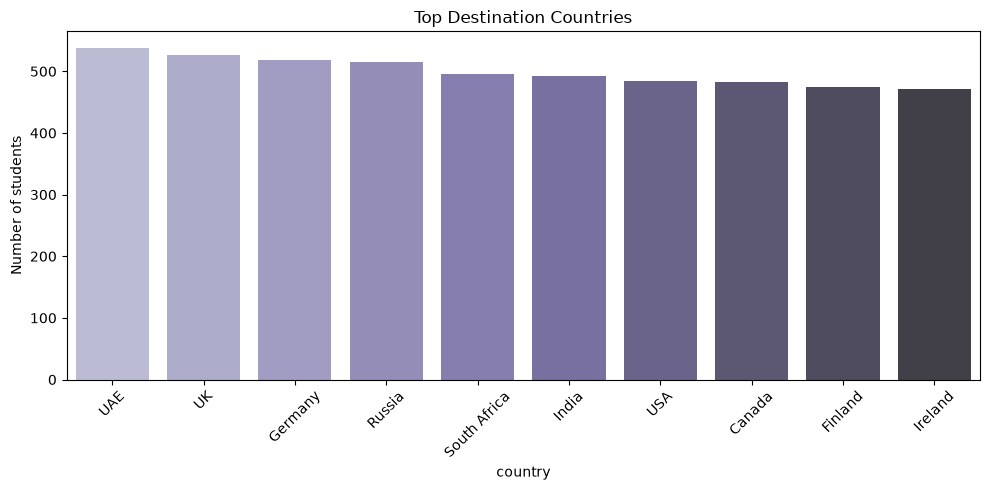

In [46]:
import pandas as pd
import seaborn as sns

#Read dataset
df = pd.read_csv("global_student_migration.csv")


#Count top destination countries
top_dest= df["destination_country"].value_counts().head(10)
print(top_dest)

#Create bar chart
plt.figure(figsize=(10,5))    #(width,height)
sns.barplot(x=top_dest.index,y=top_dest.values,hue=top_dest.index,palette='Purples_d',legend=False)

#Title and labels
plt.title("Top Destination Countries")
plt.xlabel("country")
plt.ylabel("Number of students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Students growth over years

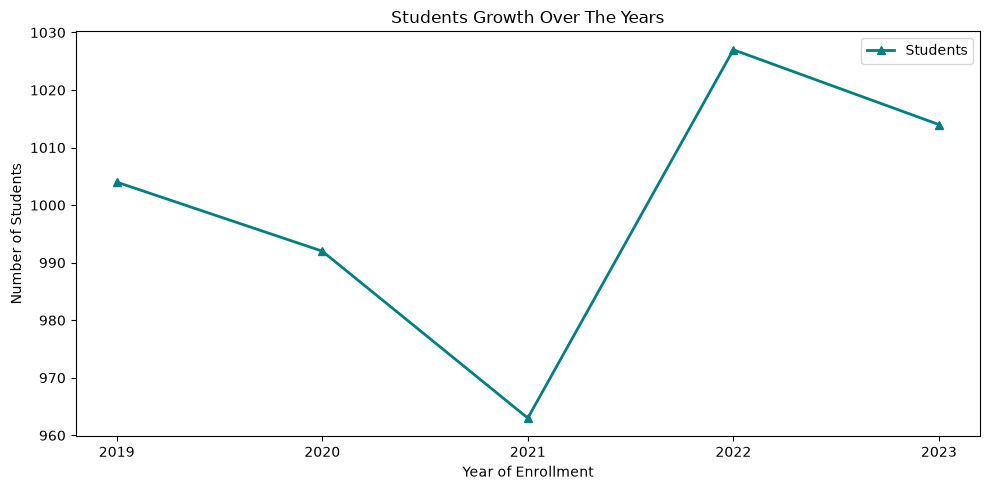

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

#Read dataset
df = pd.read_csv("global_student_migration.csv")

#Count students enrolled each year
year_count=df["year_of_enrollment"].value_counts().sort_index()

#Create line chart
plt.figure(figsize=(10,5))
plt.plot(year_count.index,year_count.values,label="Students",linestyle='-',marker='^',color="teal",linewidth=2,)

#Title and labels
plt.title("Students Growth Over The Years")
plt.xlabel("Year of Enrollment")
plt.ylabel("Number of Students")
plt.xticks([2019,2020,2021,2022,2023])
plt.legend()  
plt.tight_layout()
plt.show()      

# SCHOLARSHIP VS  NON SCHOLARSHIP COUNT

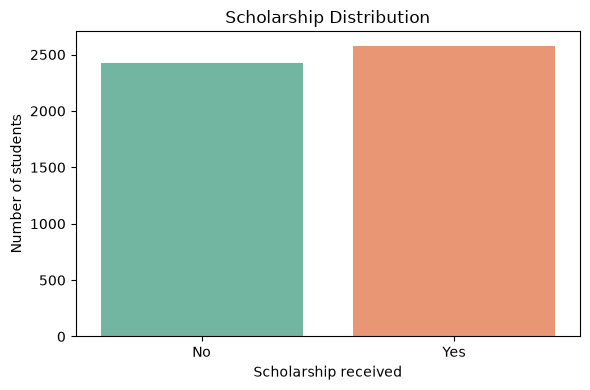

In [47]:
df = pd.read_csv("global_student_migration.csv")

plt.figure(figsize=(6,4))
sns.countplot( x='scholarship_received',data=df,hue='scholarship_received', palette = 'Set2',legend=False)

plt.title('Scholarship Distribution')
plt.xlabel('Scholarship received')
plt.ylabel('Number of students')
plt.tight_layout()
plt.show()

# Degree distribution

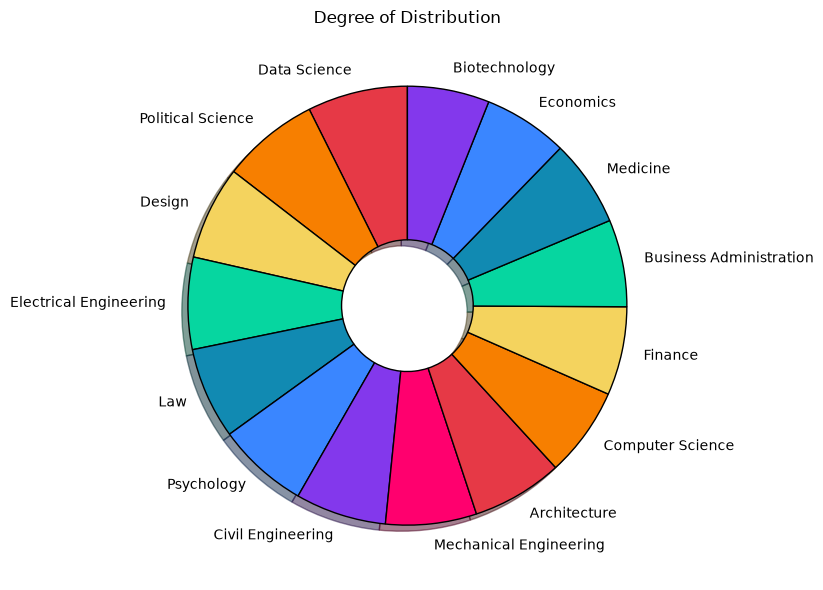

In [77]:
plt.figure(figsize=(10,6))
degree_count=df['course_name'].value_counts()

plt.pie(degree_count.values,labels=degree_count.index,colors=["#E63946","#F77F00","#F4D35E","#06D6A0","#118AB2","#3A86FF","#8338EC","#FF006E"],shadow=True,startangle=90,wedgeprops={"edgecolor":'black', 'width':0.7})
plt.title('Degree of Distribution')
plt.tight_layout()
plt.show()        

# Reason of Enrollment

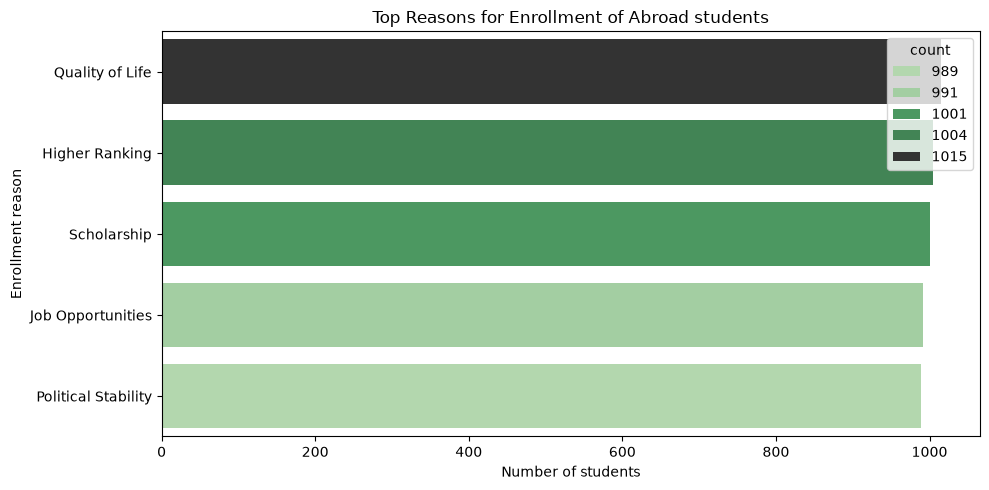

In [4]:
top_reason = df['enrollment_reason'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_reason.values,y=top_reason.index,hue=top_reason,palette='Greens_d')
plt.title("Top Reasons for Enrollment of Abroad students")
plt.xlabel("Number of students")
plt.ylabel("Enrollment reason")
plt.tight_layout()
plt.show()

In [7]:
df.columns

Index(['student_id', 'origin_country', 'destination_country',
       'destination_city', 'university_name', 'course_name', 'field_of_study',
       'year_of_enrollment', 'scholarship_received', 'enrollment_reason',
       'graduation_year', 'placement_status', 'placement_country',
       'placement_company', 'starting_salary_usd', 'gpa_or_score',
       'visa_status', 'post_graduation_visa', 'language_proficiency_test',
       'test_score'],
      dtype='str')

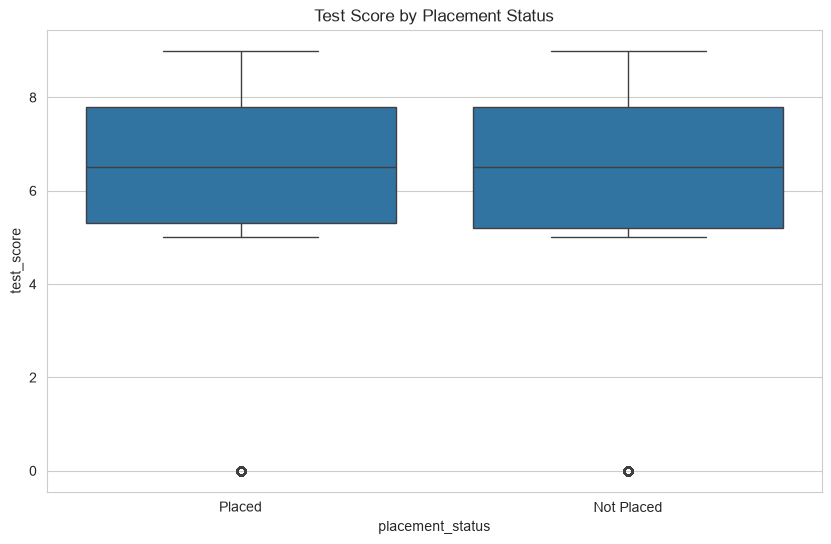

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='placement_status', y='test_score')
plt.title('Test Score by Placement Status')
plt.show()


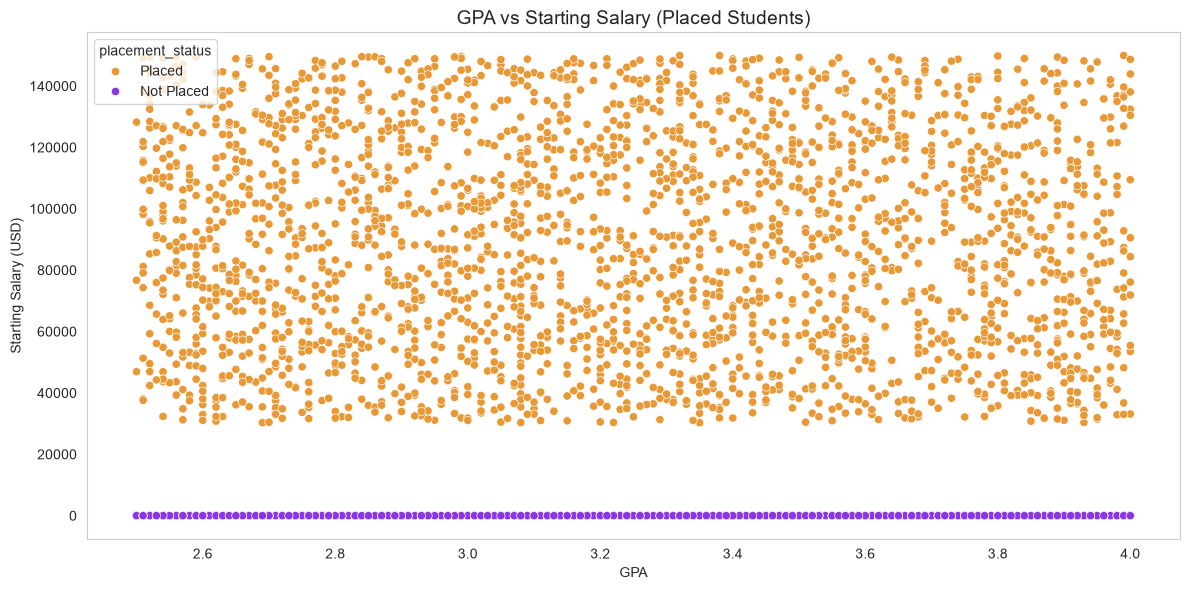

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('global_student_migration.csv')

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

markers = {'GPA':'o', 'Starting Salary (USD)':'^'}
custom_color = ['#e89835','#8935e8']

sns.scatterplot( df, x='gpa_or_score', y='starting_salary_usd', hue='placement_status',markers=markers, palette=custom_color )

plt.title('GPA vs Starting Salary (Placed Students)', fontsize=14)
plt.xlabel('GPA')
plt.ylabel('Starting Salary (USD)')
plt.tight_layout()
plt.grid()
plt.show()

# Is Computer Science still the most attractive field?

In [ ]:
'